In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

plt.style.use("default")
sns.set_context("notebook")

In [21]:
df = pd.read_csv("../data/sentiment_analysis.csv")

df.head()


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [23]:
df.describe(include="all")

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
count,499.000000,499.000000,499.000000,499,499,499,499
unique,NaN,NaN,NaN,3,394,3,5
top,NaN,NaN,NaN,morning,Grabbing coffee from then making mom breakfast,neutral,Instagram
freq,NaN,NaN,NaN,171,4,199,171
mean,2020.394790,6.084168,15.693387,NaN,NaN,NaN,NaN
std,2.830991,3.652711,8.804673,NaN,NaN,NaN,NaN
min,2010.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,2019.000000,2.000000,8.000000,NaN,NaN,NaN,NaN
50%,2021.000000,6.000000,15.000000,NaN,NaN,NaN,NaN
75%,2023.000000,9.000000,22.000000,NaN,NaN,NaN,NaN


In [24]:
# Renombrar columnas
df = df.rename(columns={
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Time of Tweet": "time",
    "text": "text",
    "sentiment": "sentiment",
    "Platform": "platform"
})

# Eliminar nulos
df = df.dropna(subset=["text", "sentiment"])

# Normalizar texto
df["text"] = df["text"].str.lower()

# Normalizar plataforma
df["platform"] = (
    df["platform"]
    .str.strip()
    .str.lower()
)

In [25]:
# Contar ocurrencias de cada sentimiento
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts


sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64

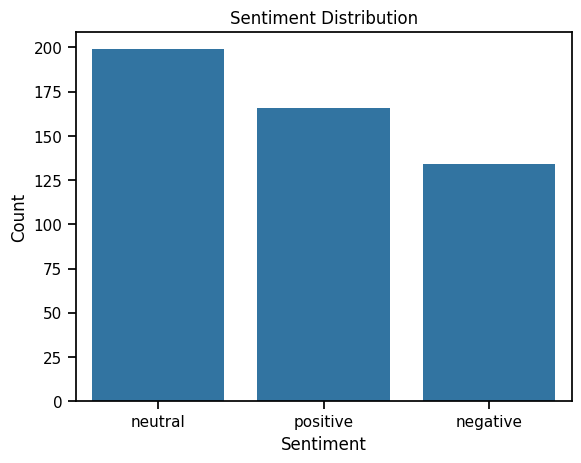

In [26]:
# Visualizar distribución de sentimientos
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [27]:
# Sentimiento por plataforma
platform_sentiment = pd.crosstab(df["platform"], df["sentiment"])

platform_sentiment

sentiment,negative,neutral,positive
platform,,,
facebook,54,54,61
instagram,49,65,57
twitter,31,80,48


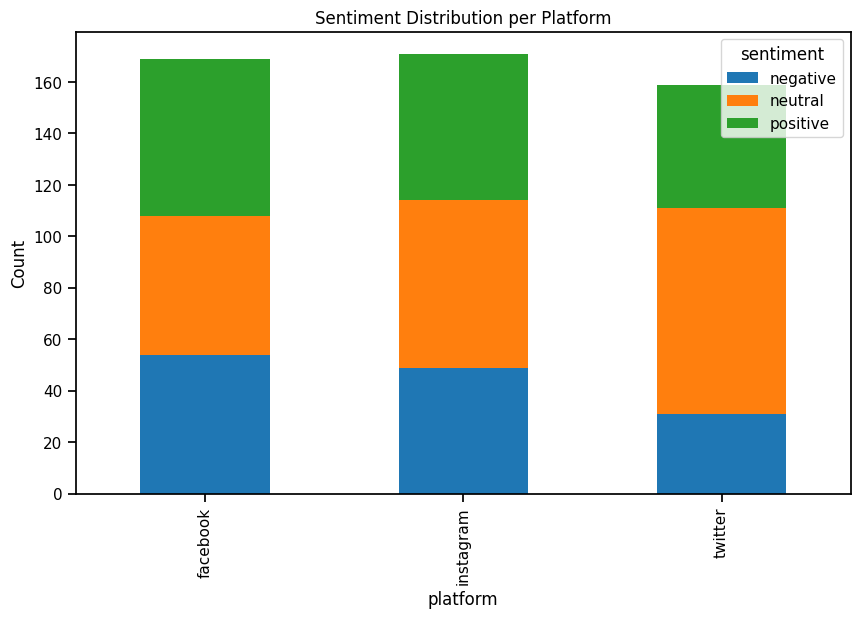

In [ ]:
# 
platform_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.title("Sentiment Distribution per Platform")
plt.ylabel("Count")
plt.show()


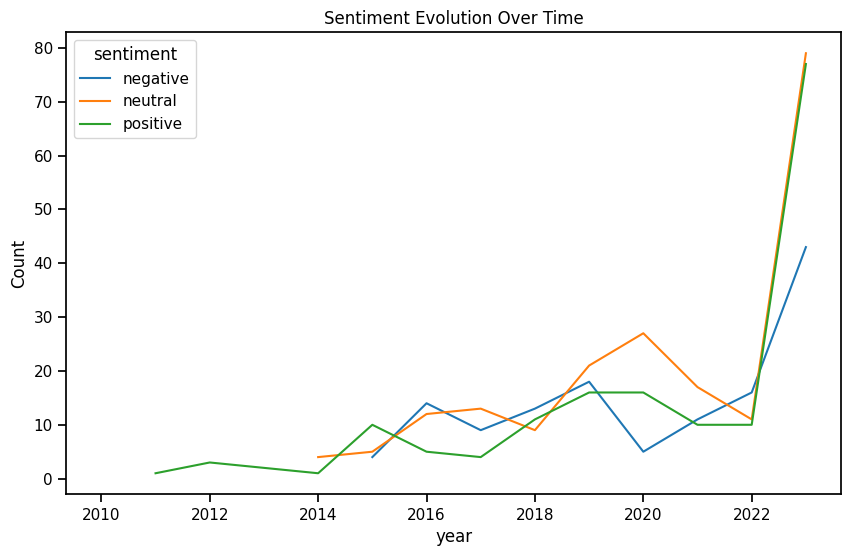

In [ ]:
# Sentimiento a lo largo del tiempo
df["date"] = pd.to_datetime(
    df[["year", "month", "day"]]
)

sentiment_by_year = df.groupby(["year", "sentiment"]).size().unstack()

sentiment_by_year.plot(figsize=(10,6))
plt.title("Sentiment Evolution Over Time")
plt.ylabel("Count")
plt.show()


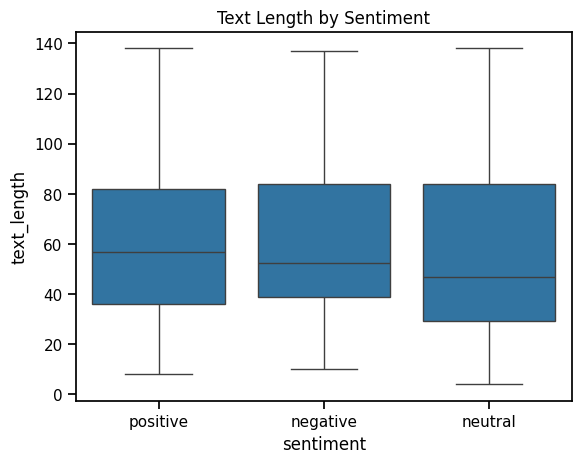

In [30]:
# Longitud del texto por sentimiento
df["text_length"] = df["text"].apply(len)

sns.boxplot(
    x="sentiment",
    y="text_length",
    data=df
)
plt.title("Text Length by Sentiment")
plt.show()


In [31]:
# Palabras más comunes por sentimiento
def top_words(df, sentiment, n=20):
    text = " ".join(df[df["sentiment"] == sentiment]["text"])
    words = text.split()
    return Counter(words).most_common(n)

top_words(df, "positive")


[('i', 64),
 ('to', 52),
 ('the', 50),
 ('a', 38),
 ('you', 32),
 ('for', 28),
 ('my', 27),
 ('and', 26),
 ('love', 24),
 ('in', 21),
 ('happy', 21),
 ('day', 19),
 ('me', 16),
 ('that', 16),
 ('have', 16),
 ('was', 16),
 ('are', 15),
 ('really', 15),
 ('it', 15),
 ('is', 14)]

In [32]:
top_words(df, "negative")

[('i', 55),
 ('to', 46),
 ('my', 35),
 ('the', 33),
 ('and', 28),
 ('in', 26),
 ('is', 26),
 ('you', 23),
 ('a', 23),
 ('for', 22),
 ('i`m', 21),
 ('it', 20),
 ('not', 19),
 ('on', 17),
 ('are', 13),
 ('just', 11),
 ('but', 11),
 ('of', 11),
 ('no', 11),
 ('me', 10)]